# EDA — RFM rolling quadrimesters: Instagram (RCEDTG) vs TikTok (RCEGT)

Exhaustive exploratory analysis of the **user-level rolling-quadrimester** RFM feature tables for the two
platforms produced under `Mickey/`:

| Platform | File | Feature set |
|---|---|---|
| Instagram | `RFM_IG_rolling_quadrimesters/ig_user_rolling_quadrimesters_new_definitions.csv` | **R**ecency, **C**overage, **E**ngagement, **D**elay, **T**enure, **G**ini |
| TikTok | `RFM_TK_rolling_quadrimesters/tk_user_rolling_quadrimesters.csv` | **R**ecency, **C**overage, **E**ngagement, **G**ini, **T**enure (binary) |

Each row is one *(user, rolling-quadrimester window)* observation. Both tables share the **same 40 rolling
4-month windows** (`2022-09 to 2022-12` … sliding monthly), which is the only axis on which the two
platforms can be compared (the user populations are disjoint: 0 shared `user_key`).

**What this notebook does**
1. Data quality & feature dictionary
2. Univariate distributions (raw + log for heavy-tailed features)
3. Within-platform pairwise relationships & correlations (Pearson + Spearman)
4. Common-feature distribution comparison IG vs TK
5. Temporal evolution of each feature across the 40 windows
6. **Cross-platform** window-aggregate correlations (the meaningful cross-platform link)
7. Summary of findings


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)

BASE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
IG_PATH = os.path.join(BASE, "RFM_IG_rolling_quadrimesters", "ig_user_rolling_quadrimesters_new_definitions.csv")
TK_PATH = os.path.join(BASE, "RFM_TK_rolling_quadrimesters", "tk_user_rolling_quadrimesters.csv")
OUT = os.path.join(BASE, "eda_rfm_outputs")
os.makedirs(OUT, exist_ok=True)

def save(fig, name):
    stem = os.path.splitext(name)[0]
    fig.savefig(os.path.join(OUT, stem + ".svg"), format="svg", bbox_inches="tight")
    fig.savefig(os.path.join(OUT, stem + ".png"), bbox_inches="tight", dpi=300)

print("Outputs ->", OUT)

Outputs -> d:\Polythecninco di Milano\AFB_Lab\Mickey\eda_rfm_outputs


In [2]:
ig = pd.read_csv(IG_PATH)
tk = pd.read_csv(TK_PATH)

# Feature groups
IG_FEATURES = ["recency", "coverage", "engagement", "delay", "tenure", "gini"]
TK_FEATURES = ["recency", "coverage", "engagement", "gini", "tenure_binary"]
COMMON      = ["recency", "coverage", "engagement", "gini"]   # continuous features present on both
# heavy-tailed -> better viewed / correlated on a log or rank scale
SKEWED      = {"engagement", "delay", "tenure"}

print("IG:", ig.shape, "| users:", ig.user_key.nunique(), "| windows:", ig.window_id.nunique())
print("TK:", tk.shape, "| users:", tk.user_key.nunique(), "| windows:", tk.window_id.nunique())
ig.head(3)

IG: (174287, 18) | users: 18752 | windows: 40
TK: (56300, 17) | users: 13249 | windows: 40


,window_id,window_label,window_index,window_start,window_end,window_total_days,posts_in_window,user_key,user_id,username,comment_count,last_comment_timestamp,recency,coverage,engagement,delay,tenure,gini
0,w01,2022-09 to 2022-12,1,2022-09-01,2022-12-31,122,64,1004178702296684,1.004179e+15,dalia_blu,1,2022-11-08 12:55:12,0.421875,0.015625,15.0,1.660833,171.774225,0.0
1,w01,2022-09 to 2022-12,1,2022-09-01,2022-12-31,122,64,1005332278491758,1.005332e+15,__silvigram,2,2022-09-07 10:44:14,0.906250,0.031250,4.0,0.096111,3.747812,0.5
2,w01,2022-09 to 2022-12,1,2022-09-01,2022-12-31,122,64,1011107228082265,1.011107e+15,fabiolaventurinii,2,2022-12-11 13:15:20,0.109375,0.031250,2.0,0.043750,44.199306,0.5


## 1. Data quality & feature dictionary

In [3]:
def quality(df, feats, name):
    rep = pd.DataFrame({
        "dtype": df[feats].dtypes.astype(str),
        "n_missing": df[feats].isna().sum(),
        "pct_missing": (df[feats].isna().mean()*100).round(2),
        "n_zero": (df[feats] == 0).sum(),
        "pct_zero": ((df[feats] == 0).mean()*100).round(2),
        "skew": df[feats].skew().round(2),
    })
    print(f"=== {name} ===")
    return rep

display(quality(ig, IG_FEATURES, "Instagram (RCEDTG)"))
display(quality(tk, TK_FEATURES, "TikTok (RCEGT)"))

=== Instagram (RCEDTG) ===


,dtype,n_missing,pct_missing,n_zero,pct_zero,skew
recency,float64,0,0.0,5587,3.21,0.18
coverage,float64,0,0.0,0,0.00,6.15
engagement,float64,0,0.0,0,0.00,4.95
delay,float64,0,0.0,0,0.00,21.03
tenure,float64,0,0.0,14982,8.60,0.31
gini,float64,0,0.0,126749,72.72,1.23


=== TikTok (RCEGT) ===


,dtype,n_missing,pct_missing,n_zero,pct_zero,skew
recency,float64,0,0.0,2472,4.39,0.06
coverage,float64,0,0.0,0,0.00,2.30
engagement,float64,0,0.0,0,0.00,15.08
gini,float64,0,0.0,53677,95.34,4.53
tenure_binary,int64,0,0.0,47019,83.52,1.81


In [4]:
print("Instagram feature summary"); display(ig[IG_FEATURES].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3))
print("TikTok feature summary");    display(tk[TK_FEATURES].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3))

Instagram feature summary


,count,mean,std,min,5%,25%,50%,75%,95%,max
recency,174287.0,0.447,0.295,0.000,0.024,0.173,0.414,0.692,0.938,1.000
coverage,174287.0,0.031,0.026,0.016,0.016,0.019,0.023,0.033,0.070,0.580
engagement,174287.0,8.830,10.324,1.000,1.000,3.000,6.000,11.000,26.000,274.000
delay,174287.0,76.727,724.893,0.004,0.114,0.631,2.293,8.492,93.674,25620.938
tenure,174287.0,1043.151,775.533,0.000,0.000,335.915,1009.545,1631.019,2381.040,3460.245
gini,174287.0,0.158,0.265,0.000,0.000,0.000,0.000,0.500,0.667,0.970


TikTok feature summary


,count,mean,std,min,5%,25%,50%,75%,95%,max
recency,56300.0,0.461,0.292,0.000,0.019,0.208,0.452,0.70,0.935,1.000
coverage,56300.0,0.044,0.024,0.018,0.019,0.026,0.040,0.05,0.091,0.500
engagement,56300.0,6.980,8.240,1.000,1.000,2.000,5.000,9.00,20.000,459.000
gini,56300.0,0.025,0.115,0.000,0.000,0.000,0.000,0.00,0.000,0.923
tenure_binary,56300.0,0.165,0.371,0.000,0.000,0.000,0.000,0.00,1.000,1.000


**Feature dictionary**

- **recency** – normalised time since the user's last comment within the window (1 = commented at window start side / 0 = at the very end). Bounded [0,1].
- **coverage** – share of the window's posts the user commented on (`comment_count / posts_in_window`). Bounded, right-skewed.
- **engagement** – average likes/engagement received per comment (count). Heavy right tail.
- **delay** *(IG only)* – mean delay (hours/days) between a post and the user's comment. Extremely heavy-tailed.
- **tenure** *(IG: continuous days; TK: binary)* – how long the user has been active before the window.
- **gini** – inequality of the user's commenting distribution over posts (0 when a user makes ≤1 comment, hence the spike at 0).


## 2. Univariate distributions

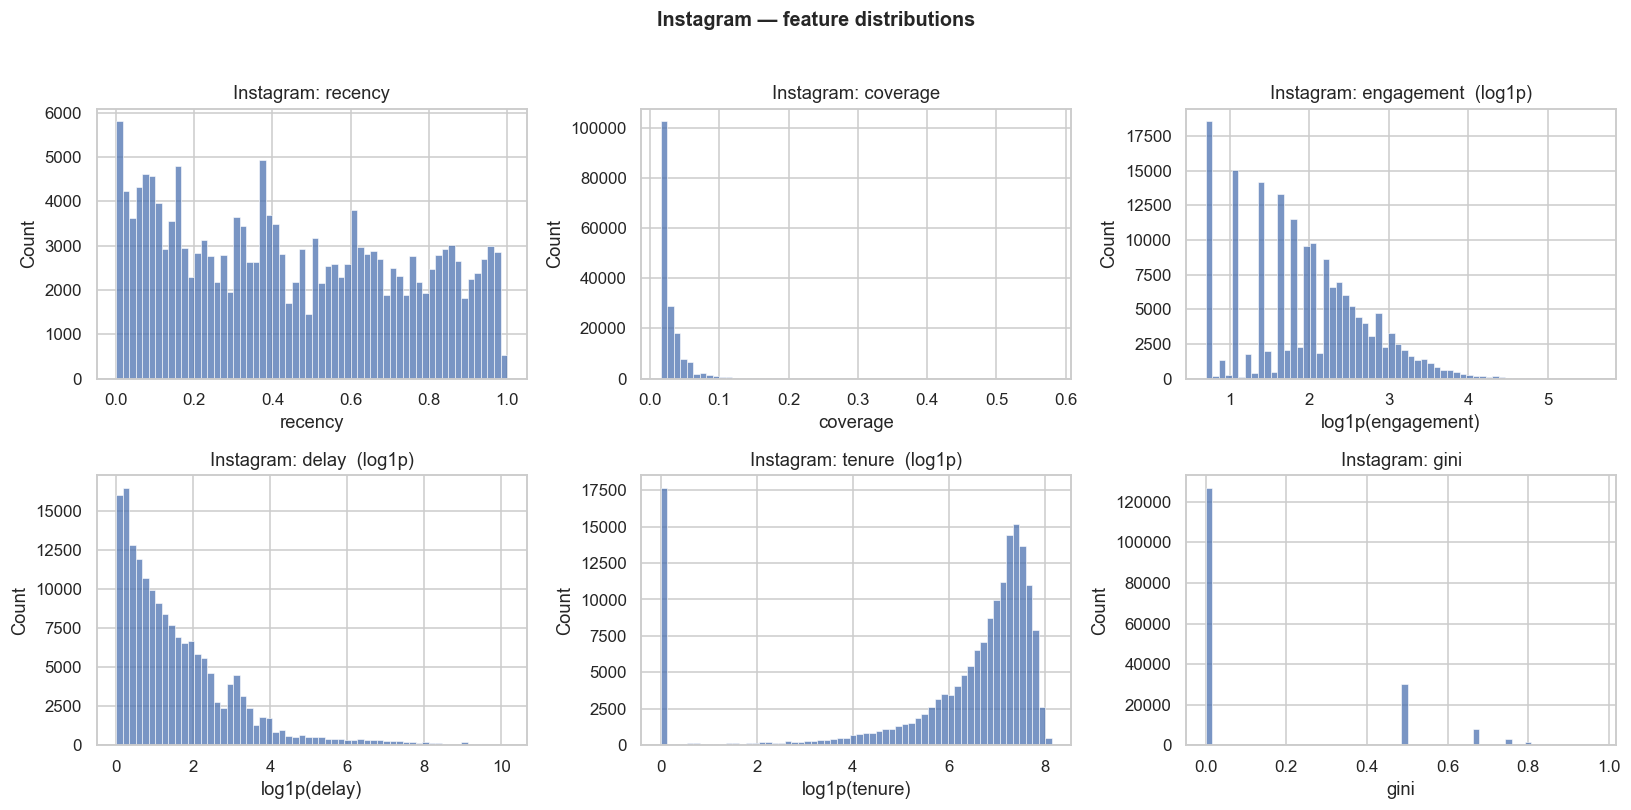

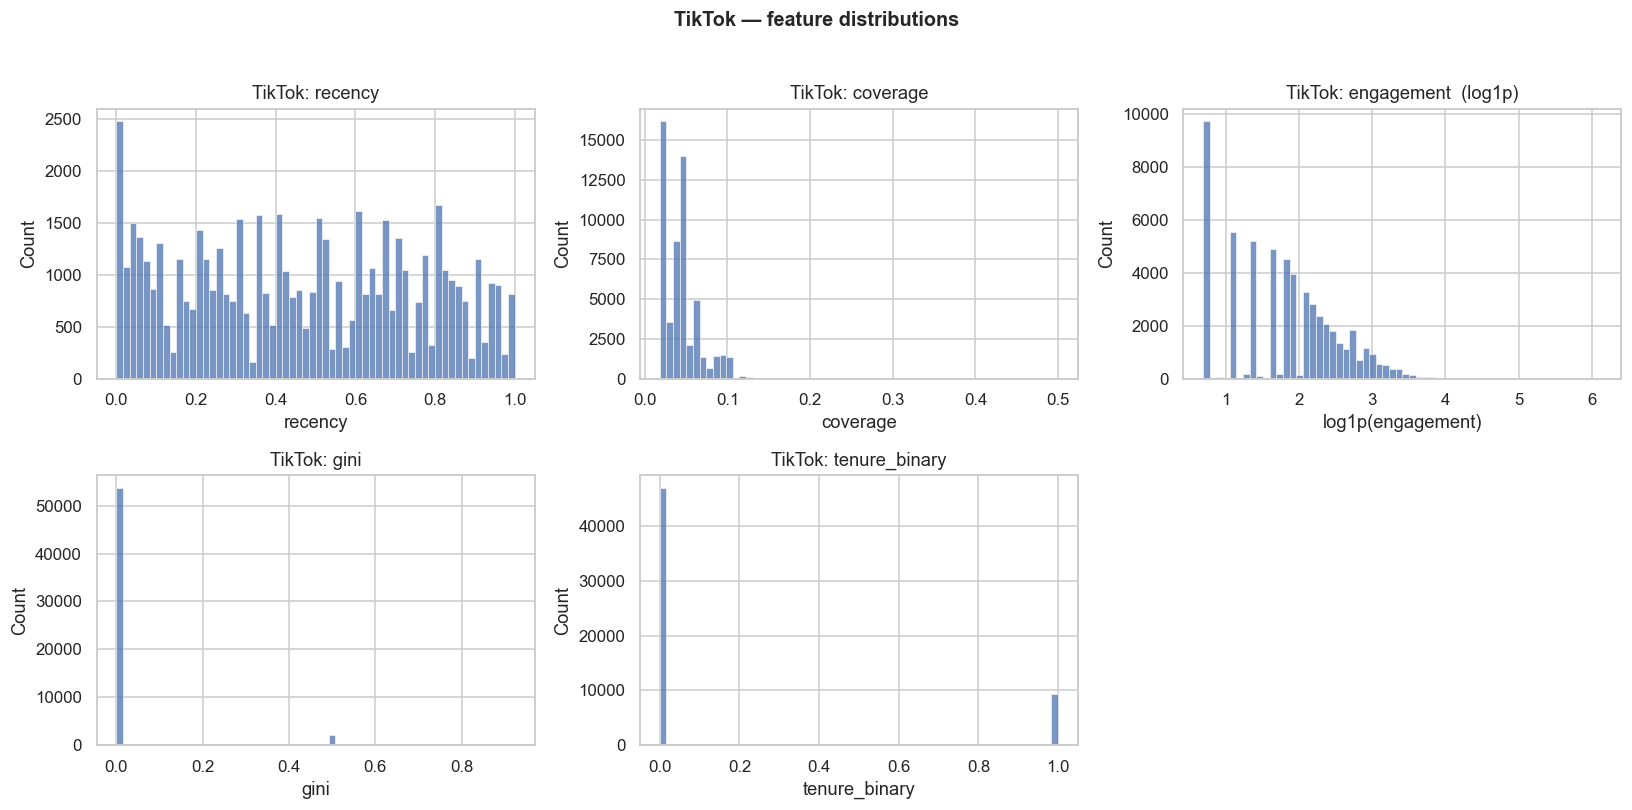

In [5]:
def dist_grid(df, feats, name, fname):
    n = len(feats); cols = 3; rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.6*rows))
    axes = np.array(axes).ravel()
    for ax, f in zip(axes, feats):
        x = df[f].dropna()
        logd = f in SKEWED
        data = np.log1p(x) if logd else x
        sns.histplot(data, bins=60, ax=ax, color="#4C72B0", edgecolor=None)
        ax.set_title(f"{name}: {f}" + ("  (log1p)" if logd else ""))
        ax.set_xlabel("log1p("+f+")" if logd else f)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{name} — feature distributions", y=1.02, fontsize=13, fontweight="bold")
    fig.tight_layout(); save(fig, fname); plt.show()

dist_grid(ig, IG_FEATURES, "Instagram", "ig_distributions.png")
dist_grid(tk, TK_FEATURES, "TikTok", "tk_distributions.png")

Heavy-tailed features (`engagement`, `delay`, `tenure`) are shown on a `log1p` scale. `gini` and TikTok
`tenure_binary` are spike-at-zero variables — the zero mass corresponds to single-comment users in the window.

## 3. Common-feature comparison: IG vs TK

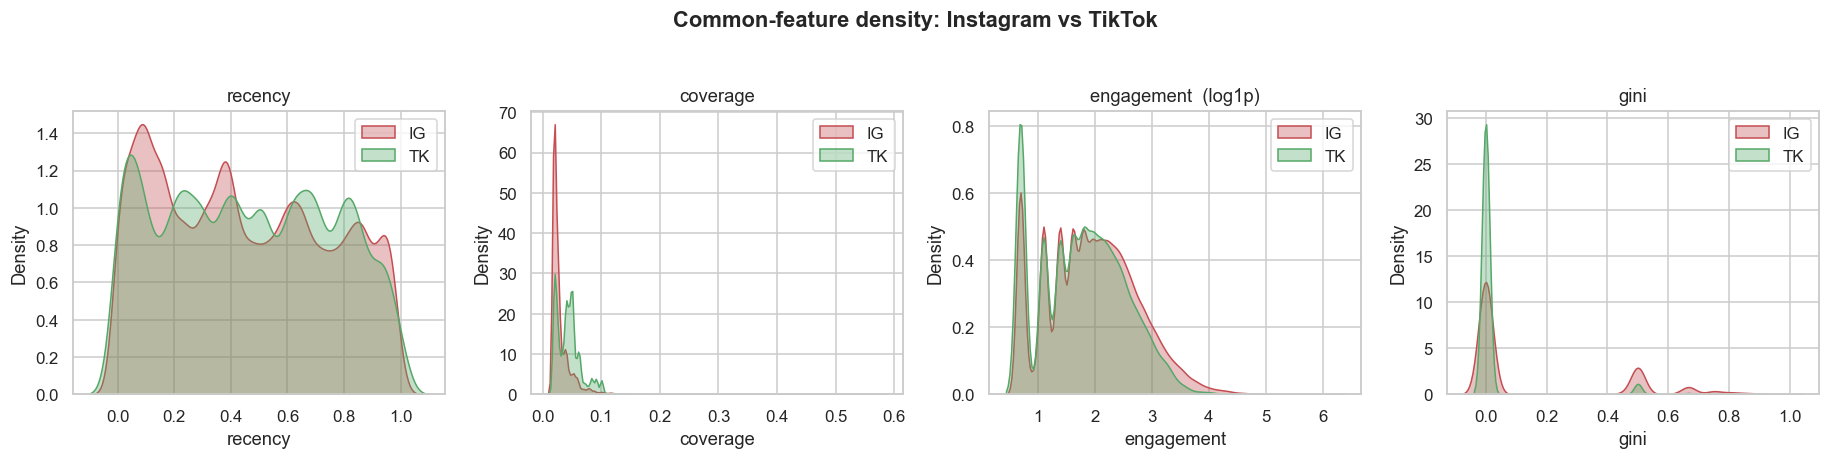

In [6]:
fig, axes = plt.subplots(1, len(COMMON), figsize=(4.2*len(COMMON), 4))
for ax, f in zip(axes, COMMON):
    a = ig[f].dropna(); b = tk[f].dropna()
    if f in SKEWED:
        a, b = np.log1p(a), np.log1p(b)
    sns.kdeplot(a, ax=ax, label="IG", fill=True, alpha=.35, color="#C44E52")
    sns.kdeplot(b, ax=ax, label="TK", fill=True, alpha=.35, color="#55A868")
    ax.set_title(f + ("  (log1p)" if f in SKEWED else "")); ax.legend()
fig.suptitle("Common-feature density: Instagram vs TikTok", y=1.04, fontweight="bold")
fig.tight_layout(); save(fig, "common_feature_density.png"); plt.show()

In [7]:
# Distribution-shift tests on shared continuous features (independent populations)
rows = []
for f in COMMON:
    a, b = ig[f].dropna(), tk[f].dropna()
    ks, ks_p = stats.ks_2samp(a, b)
    u, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({"feature": f, "IG_median": a.median(), "TK_median": b.median(),
                 "KS_stat": ks, "KS_p": ks_p, "MWU_p": u_p})
pd.DataFrame(rows).round(4)

,feature,IG_median,TK_median,KS_stat,KS_p,MWU_p
0,recency,0.4138,0.4516,0.0483,0.0,0.0
1,coverage,0.0227,0.0400,0.4330,0.0,0.0
2,engagement,6.0000,5.0000,0.0792,0.0,0.0
3,gini,0.0000,0.0000,0.2262,0.0,0.0


## 4. Within-platform correlations (Pearson + Spearman)

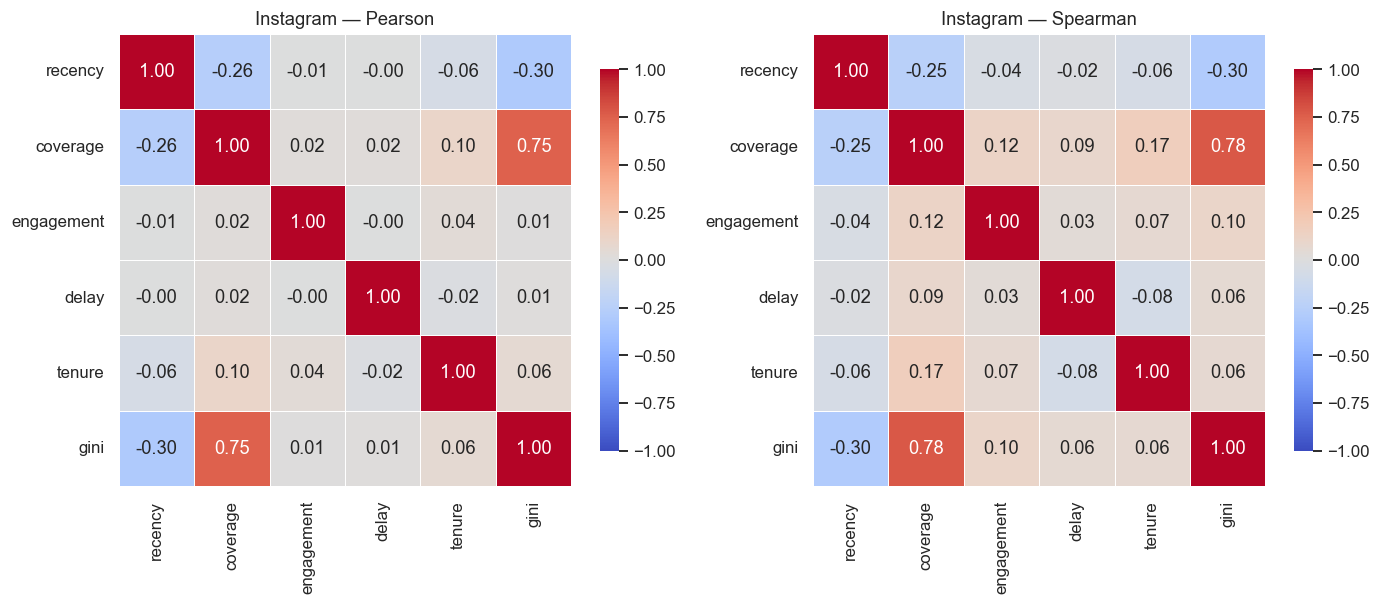

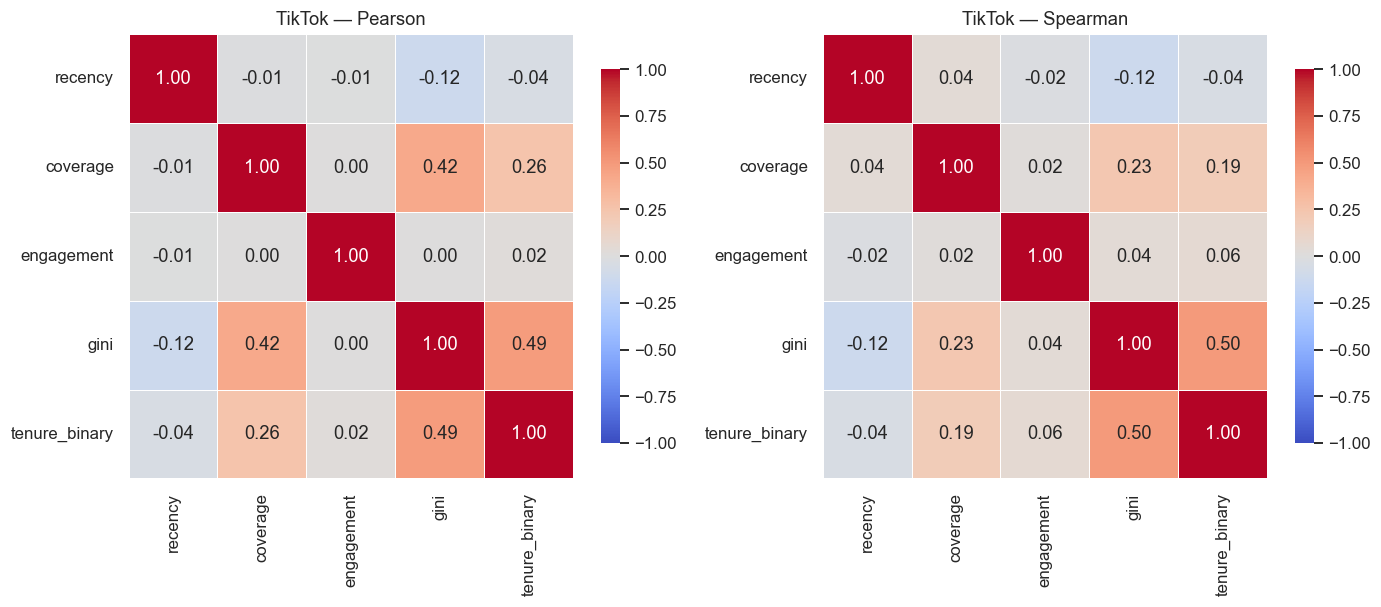

In [8]:
def corr_panel(df, feats, name, fname):
    pear = df[feats].corr(method="pearson")
    spear = df[feats].corr(method="spearman")
    fig, axes = plt.subplots(1, 2, figsize=(6.4*2, 5.4))
    for ax, m, t in [(axes[0], pear, "Pearson"), (axes[1], spear, "Spearman")]:
        sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                    square=True, linewidths=.5, cbar_kws={"shrink":.8}, ax=ax)
        ax.set_title(f"{name} — {t}")
    fig.tight_layout(); save(fig, fname); plt.show()
    return pear, spear

ig_p, ig_s = corr_panel(ig, IG_FEATURES, "Instagram", "ig_corr_heatmap.png")
tk_p, tk_s = corr_panel(tk, TK_FEATURES, "TikTok", "tk_corr_heatmap.png")

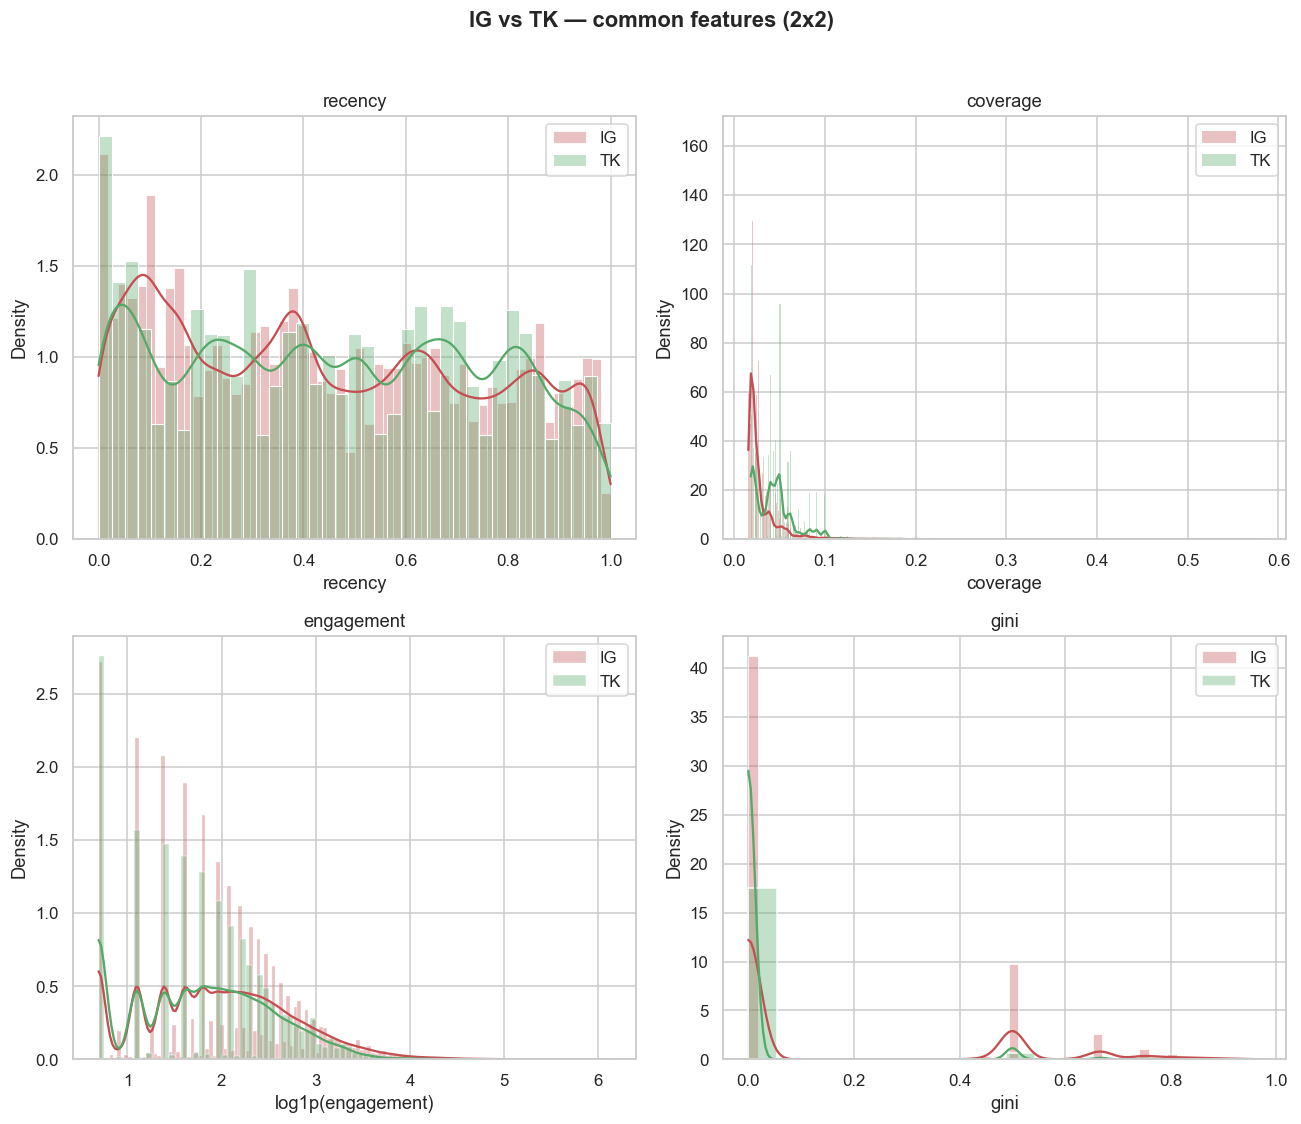

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, f in zip(axes, COMMON):
    ig_data = ig[f].dropna()
    tk_data = tk[f].dropna()

    if f in SKEWED:
        ig_data = np.log1p(ig_data)
        tk_data = np.log1p(tk_data)
        xlabel = f"log1p({f})"
    else:
        xlabel = f

    sns.histplot(ig_data, ax=ax, color="#C44E52", label="IG", stat="density", kde=True, alpha=0.35)
    sns.histplot(tk_data, ax=ax, color="#55A868", label="TK", stat="density", kde=True, alpha=0.35)
    ax.set_title(f)
    ax.set_xlabel(xlabel)
    ax.legend()

fig.suptitle("IG vs TK — common features (2x2)", y=1.02, fontweight="bold")
fig.tight_layout()
plt.show()

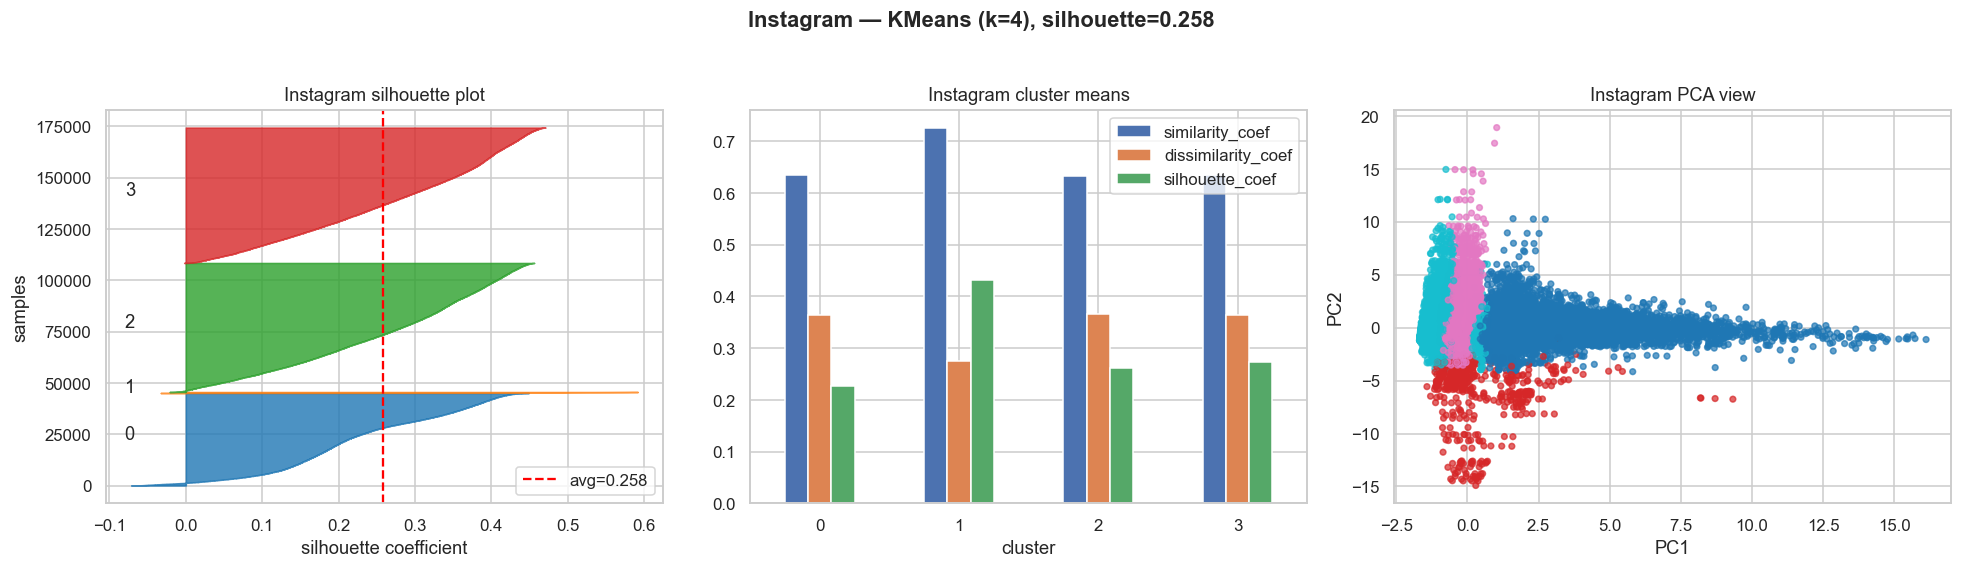

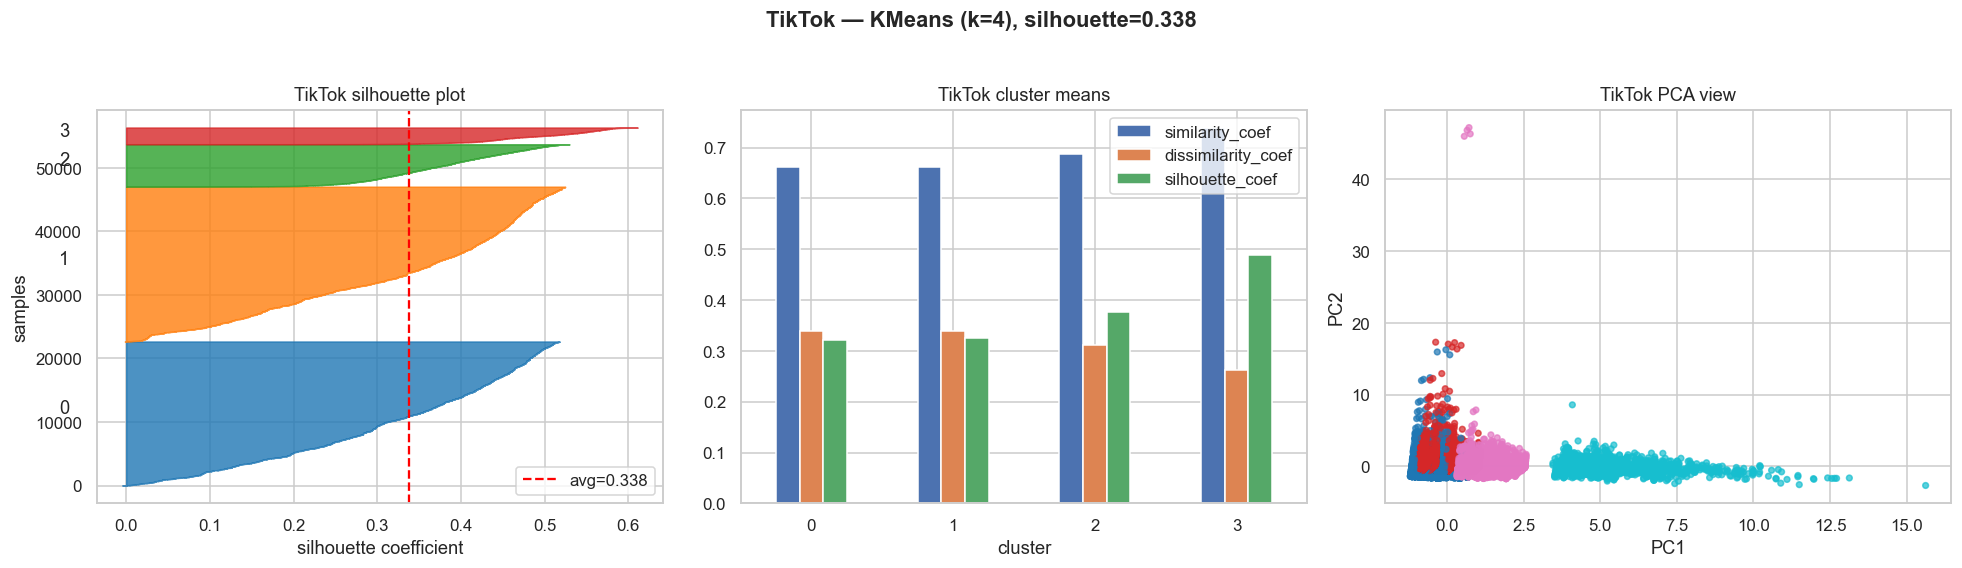

Instagram silhouette: 0.2579


,similarity_coef,dissimilarity_coef,silhouette_coef
cluster,,,
0,0.636,0.364,0.228
1,0.725,0.275,0.432
2,0.633,0.367,0.261
3,0.635,0.365,0.274



TikTok silhouette: 0.3378


,similarity_coef,dissimilarity_coef,silhouette_coef
cluster,,,
0,0.662,0.338,0.322
1,0.662,0.338,0.326
2,0.688,0.312,0.377
3,0.738,0.262,0.489


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

def kmeans_4_eval(df, feats, name):
    X = df[feats].astype(float).copy()
    X = X.fillna(X.median(numeric_only=True))
    Xs = StandardScaler().fit_transform(X)

    km = KMeans(n_clusters=4, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    centers = km.cluster_centers_

    # distances to own cluster center and nearest other center
    d = np.linalg.norm(Xs[:, None, :] - centers[None, :, :], axis=2)
    own = d[np.arange(len(Xs)), labels]
    d_other = d.copy()
    d_other[np.arange(len(Xs)), labels] = np.inf
    nearest_other = d_other.min(axis=1)

    denom = own + nearest_other + 1e-12
    similarity_coef = nearest_other / denom
    dissimilarity_coef = own / denom
    sil_samples = silhouette_samples(Xs, labels)
    sil_avg = silhouette_score(Xs, labels)

    out = df.copy()
    out["cluster"] = labels
    out["similarity_coef"] = similarity_coef
    out["dissimilarity_coef"] = dissimilarity_coef
    out["silhouette_coef"] = sil_samples

    summary = out.groupby("cluster")[["similarity_coef", "dissimilarity_coef", "silhouette_coef"]].mean()

    pca = PCA(n_components=2, random_state=42).fit_transform(Xs)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # silhouette plot
    y_lower = 10
    colors = sns.color_palette("tab10", 4)
    for i, c in enumerate(sorted(np.unique(labels))):
        vals = np.sort(sil_samples[labels == c])
        y_upper = y_lower + len(vals)
        axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=colors[i], alpha=0.8)
        axes[0].text(-0.08, y_lower + 0.5 * len(vals), str(c))
        y_lower = y_upper + 10
    axes[0].axvline(sil_avg, color="red", linestyle="--", label=f"avg={sil_avg:.3f}")
    axes[0].set_title(f"{name} silhouette plot")
    axes[0].set_xlabel("silhouette coefficient")
    axes[0].set_ylabel("samples")
    axes[0].legend()

    summary.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"{name} cluster means")
    axes[1].set_xlabel("cluster")
    axes[1].tick_params(axis="x", rotation=0)

    axes[2].scatter(pca[:, 0], pca[:, 1], c=labels, cmap="tab10", s=14, alpha=0.7)
    axes[2].set_title(f"{name} PCA view")
    axes[2].set_xlabel("PC1")
    axes[2].set_ylabel("PC2")

    fig.suptitle(f"{name} — KMeans (k=4), silhouette={sil_avg:.3f}", y=1.03, fontweight="bold")
    fig.tight_layout()
    plt.show()

    return out, summary, sil_avg

ig_clustered, ig_cluster_summary, ig_sil = kmeans_4_eval(ig, IG_FEATURES, "Instagram")
tk_clustered, tk_cluster_summary, tk_sil = kmeans_4_eval(tk, TK_FEATURES, "TikTok")

print(f"Instagram silhouette: {ig_sil:.4f}")
display(ig_cluster_summary.round(3))

print(f"\nTikTok silhouette: {tk_sil:.4f}")
display(tk_cluster_summary.round(3))

In [11]:
!pip install -q statsmodels


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for Instagram features
ig_vif = pd.DataFrame({
    "feature": IG_FEATURES,
    "VIF": [variance_inflation_factor(ig[IG_FEATURES].values, i) for i in range(len(IG_FEATURES))]
}).sort_values("VIF", ascending=False)

print("=== Instagram VIF ===")
display(ig_vif)

# Calculate VIF for TikTok features
tk_vif = pd.DataFrame({
    "feature": TK_FEATURES,
    "VIF": [variance_inflation_factor(tk[TK_FEATURES].values, i) for i in range(len(TK_FEATURES))]
}).sort_values("VIF", ascending=False)

print("\n=== TikTok VIF ===")
display(tk_vif)

=== Instagram VIF ===


,feature,VIF
1,coverage,4.818454
5,gini,3.178547
4,tenure,2.312606
0,recency,2.074235
2,engagement,1.606306
3,delay,1.010587



=== TikTok VIF ===


,feature,VIF
1,coverage,3.093106
0,recency,2.512890
4,tenure_binary,1.575559
2,engagement,1.565106
3,gini,1.552193


In [13]:
# Rank all within-platform feature pairs by |Spearman| (rank corr is robust to the heavy tails)
def ranked_pairs(spear, name):
    m = spear.copy().abs()
    pairs = (m.where(np.triu(np.ones(m.shape), 1).astype(bool))
               .stack().rename("abs_spearman").reset_index())
    pairs["spearman"] = [spear.loc[a, b] for a, b in zip(pairs.level_0, pairs.level_1)]
    pairs = pairs.sort_values("abs_spearman", ascending=False)
    pairs.insert(0, "platform", name)
    return pairs[["platform", "level_0", "level_1", "spearman", "abs_spearman"]]

ranked = pd.concat([ranked_pairs(ig_s, "IG"), ranked_pairs(tk_s, "TK")], ignore_index=True)
ranked.round(3)

,platform,level_0,level_1,spearman,abs_spearman
0,IG,coverage,gini,0.780,0.780
1,IG,recency,gini,-0.297,0.297
2,IG,recency,coverage,-0.248,0.248
3,IG,coverage,tenure,0.169,0.169
4,IG,coverage,engagement,0.121,0.121
5,IG,engagement,gini,0.103,0.103
6,IG,coverage,delay,0.087,0.087
7,IG,delay,tenure,-0.077,0.077
8,IG,engagement,tenure,0.068,0.068
9,IG,tenure,gini,0.063,0.063


## 5. Pairwise relationships (scatter matrices + focused pairs)

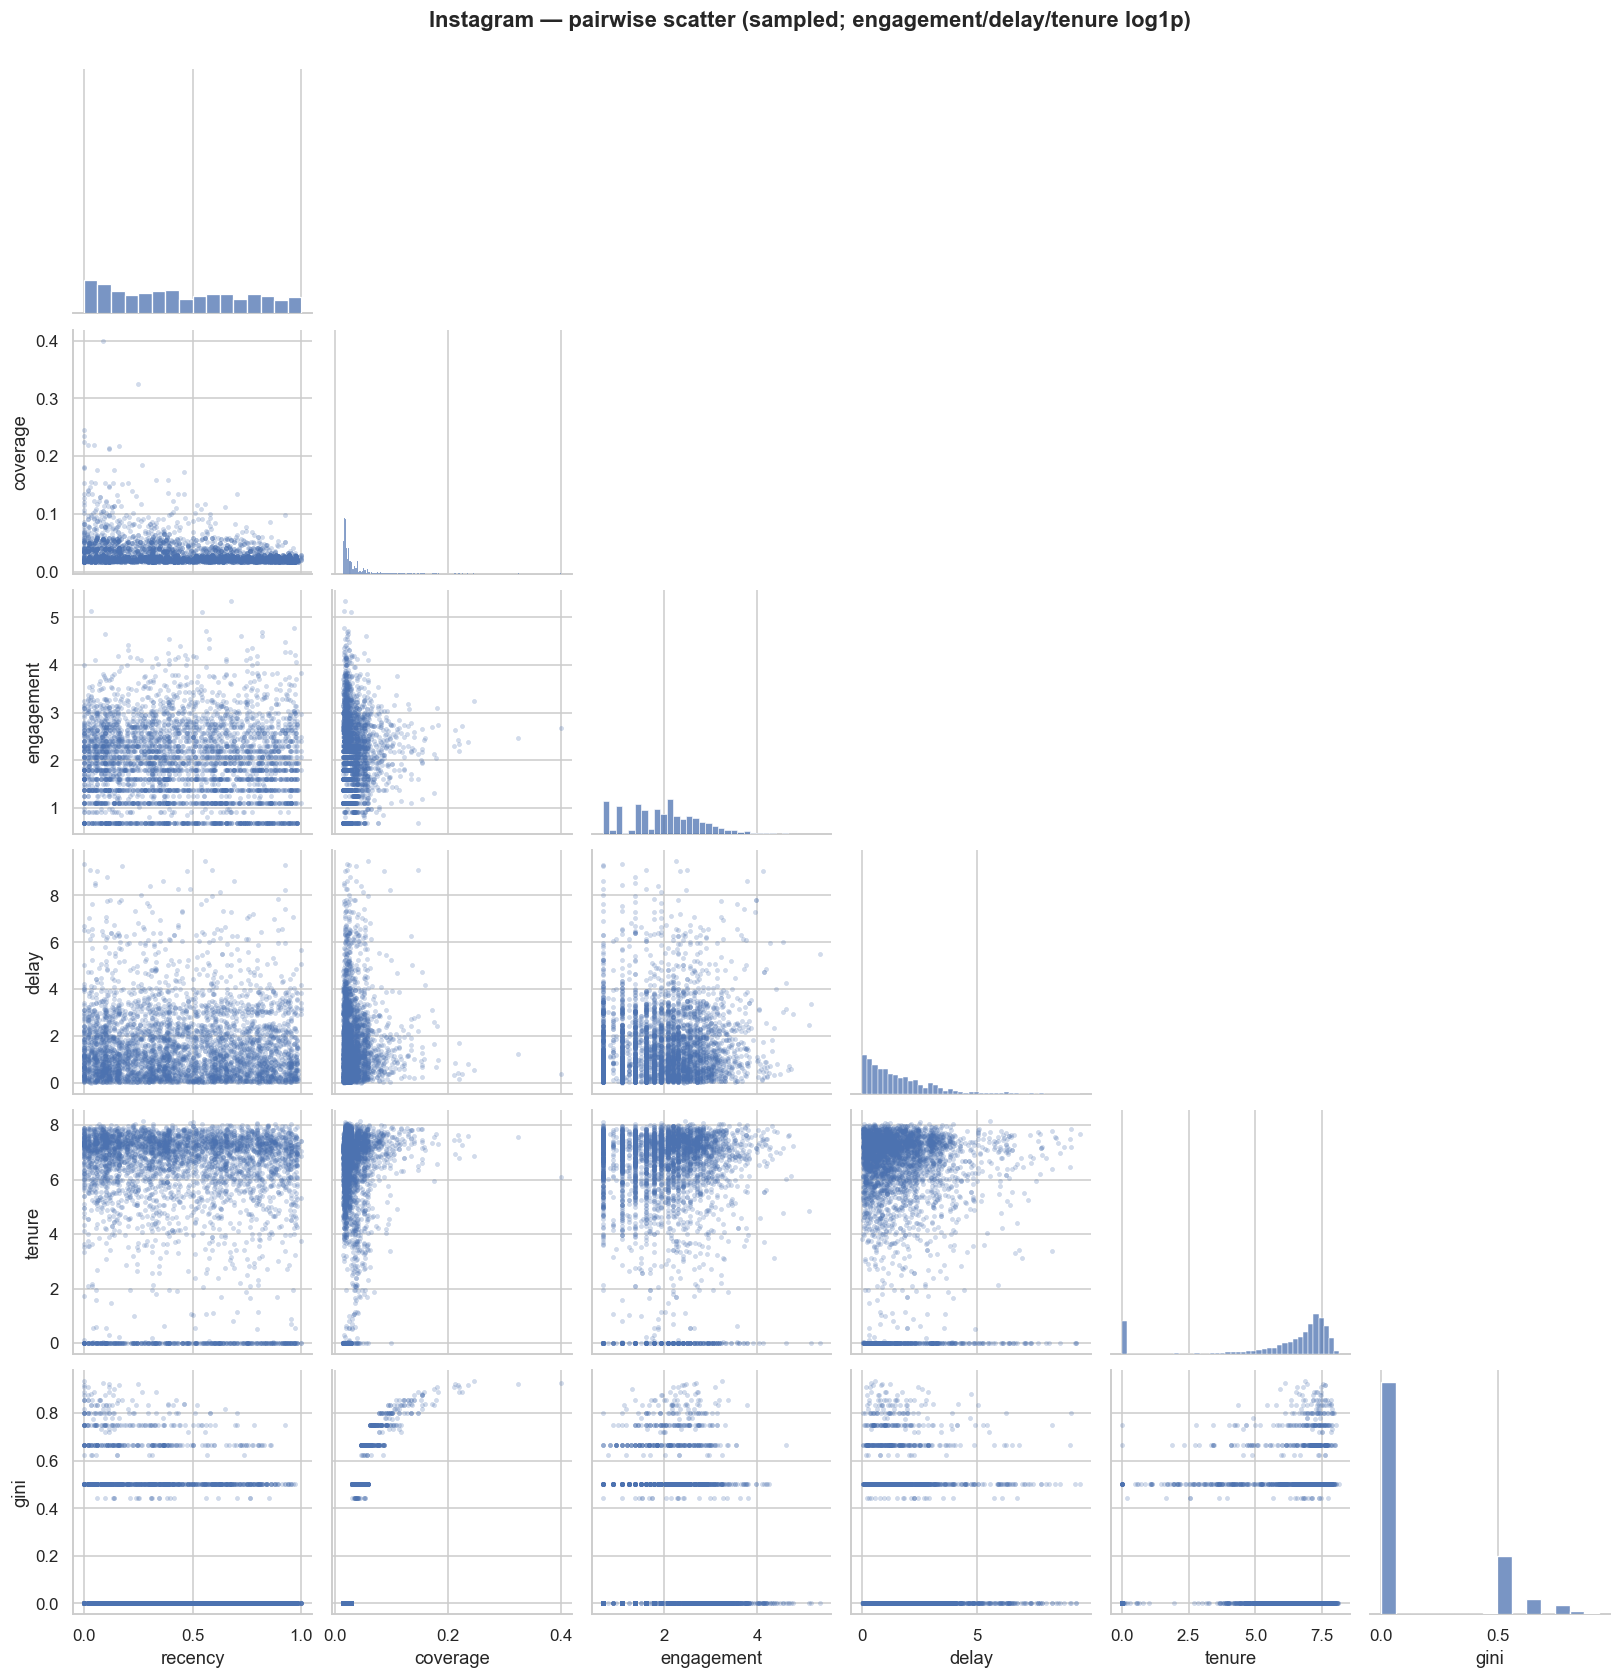

In [14]:
# Sampled pairplot keeps rendering fast on ~170k rows
ig_s_sample = ig.sample(min(4000, len(ig)), random_state=42).copy()
for f in ["engagement", "delay", "tenure"]:
    ig_s_sample[f] = np.log1p(ig_s_sample[f])
g = sns.pairplot(ig_s_sample[IG_FEATURES], plot_kws=dict(s=8, alpha=.25, edgecolor=None),
                 diag_kind="hist", corner=True)
g.fig.suptitle("Instagram — pairwise scatter (sampled; engagement/delay/tenure log1p)", y=1.02, fontweight="bold")
g.savefig(os.path.join(OUT, "ig_pairplot.svg"), format="svg", bbox_inches="tight")
g.savefig(os.path.join(OUT, "ig_pairplot.png"), bbox_inches="tight", dpi=300)
plt.show()

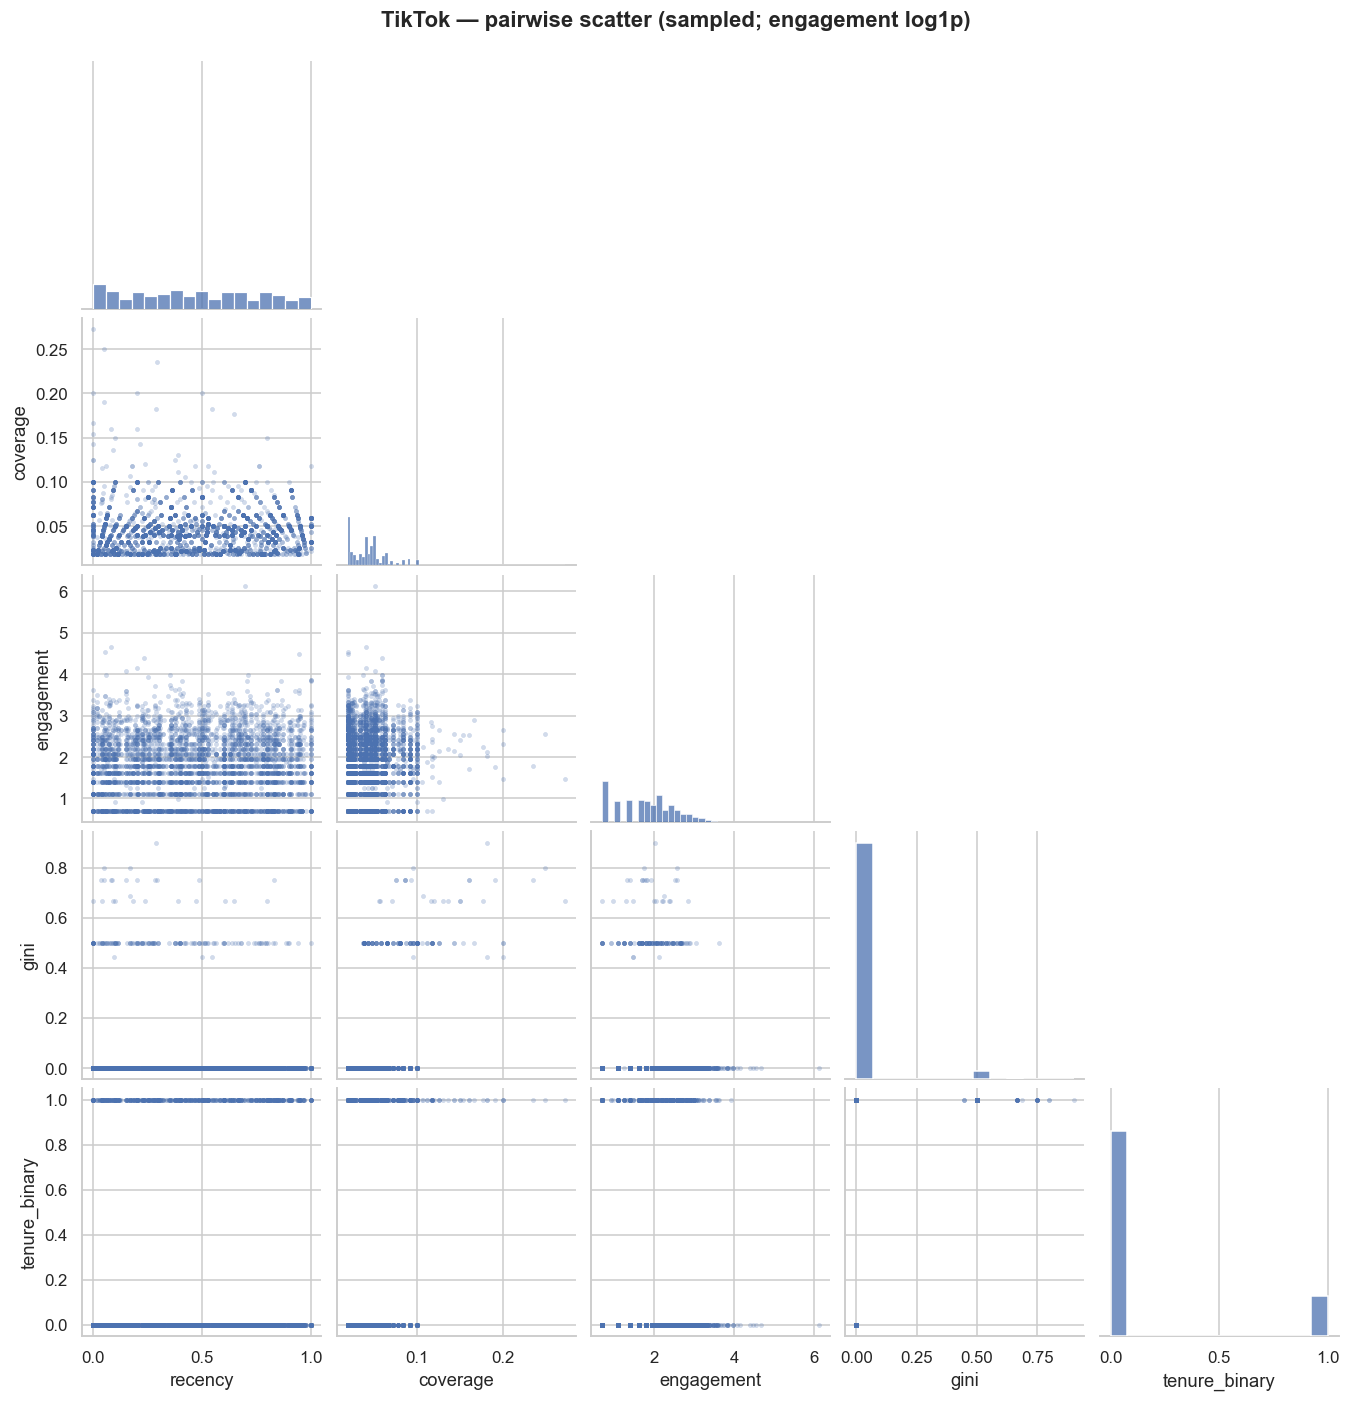

In [15]:
tk_s_sample = tk.sample(min(4000, len(tk)), random_state=42).copy()
tk_s_sample["engagement"] = np.log1p(tk_s_sample["engagement"])
g = sns.pairplot(tk_s_sample[TK_FEATURES], plot_kws=dict(s=8, alpha=.25, edgecolor=None),
                 diag_kind="hist", corner=True)
g.fig.suptitle("TikTok — pairwise scatter (sampled; engagement log1p)", y=1.02, fontweight="bold")
g.savefig(os.path.join(OUT, "tk_pairplot.svg"), format="svg", bbox_inches="tight")
g.savefig(os.path.join(OUT, "tk_pairplot.png"), bbox_inches="tight", dpi=300)
plt.show()

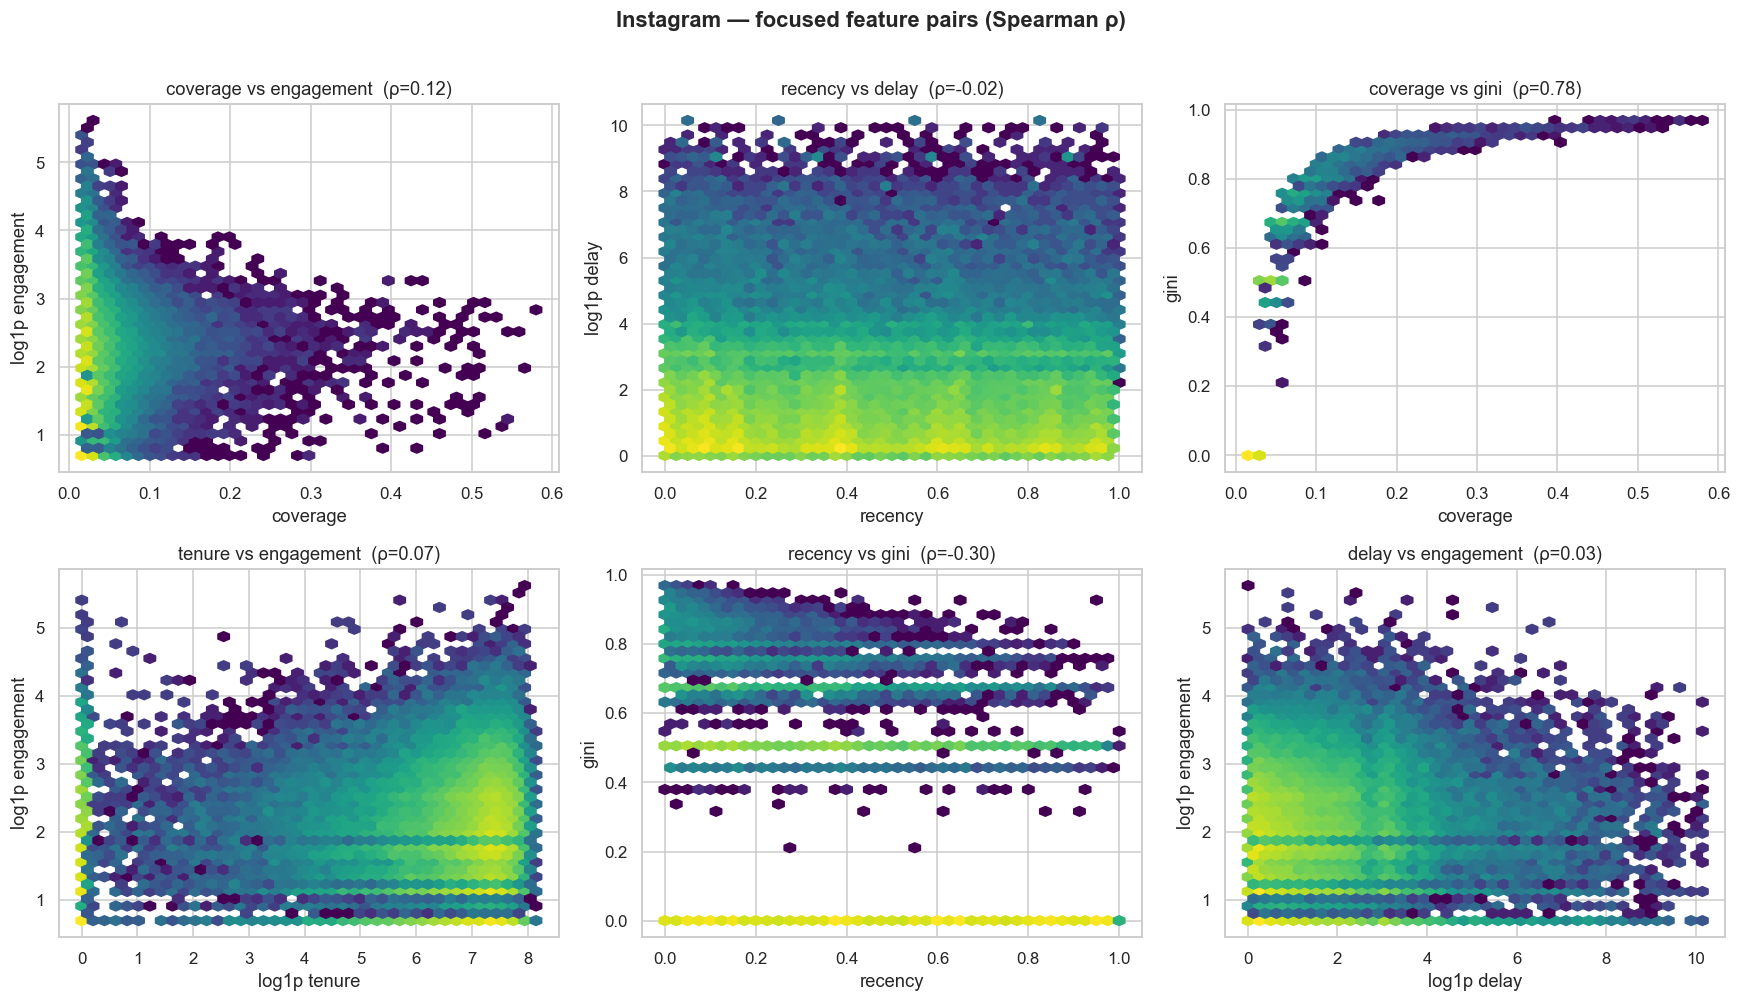

In [16]:
# Focused, interpretable pairs (hexbin handles the density of many overlapping points)
def hexpair(df, x, y, ax, logx=False, logy=False):
    dx = np.log1p(df[x]) if logx else df[x]
    dy = np.log1p(df[y]) if logy else df[y]
    ax.hexbin(dx, dy, gridsize=40, cmap="viridis", mincnt=1, bins="log")
    r = stats.spearmanr(dx, dy, nan_policy="omit").correlation
    ax.set_xlabel(("log1p " if logx else "")+x); ax.set_ylabel(("log1p " if logy else "")+y)
    ax.set_title(f"{x} vs {y}  (ρ={r:.2f})")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
hexpair(ig, "coverage", "engagement", axes[0,0], logy=True)
hexpair(ig, "recency", "delay", axes[0,1], logy=True)
hexpair(ig, "coverage", "gini", axes[0,2])
hexpair(ig, "tenure", "engagement", axes[1,0], logx=True, logy=True)
hexpair(ig, "recency", "gini", axes[1,1])
hexpair(ig, "delay", "engagement", axes[1,2], logx=True, logy=True)
fig.suptitle("Instagram — focused feature pairs (Spearman ρ)", y=1.01, fontweight="bold")
fig.tight_layout(); save(fig, "ig_focused_pairs.png"); plt.show()

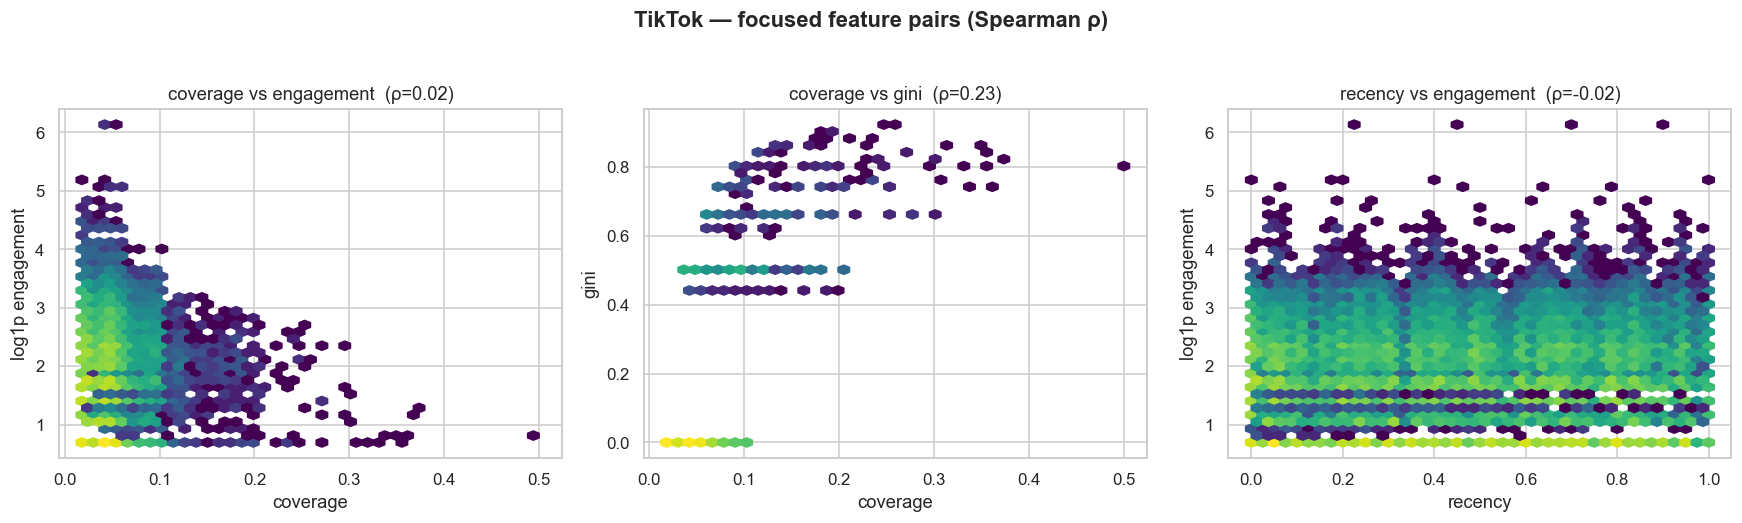

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
hexpair(tk, "coverage", "engagement", axes[0], logy=True)
hexpair(tk, "coverage", "gini", axes[1])
hexpair(tk, "recency", "engagement", axes[2], logy=True)
fig.suptitle("TikTok — focused feature pairs (Spearman ρ)", y=1.03, fontweight="bold")
fig.tight_layout(); save(fig, "tk_focused_pairs.png"); plt.show()

## 6. Temporal evolution across the 40 rolling windows

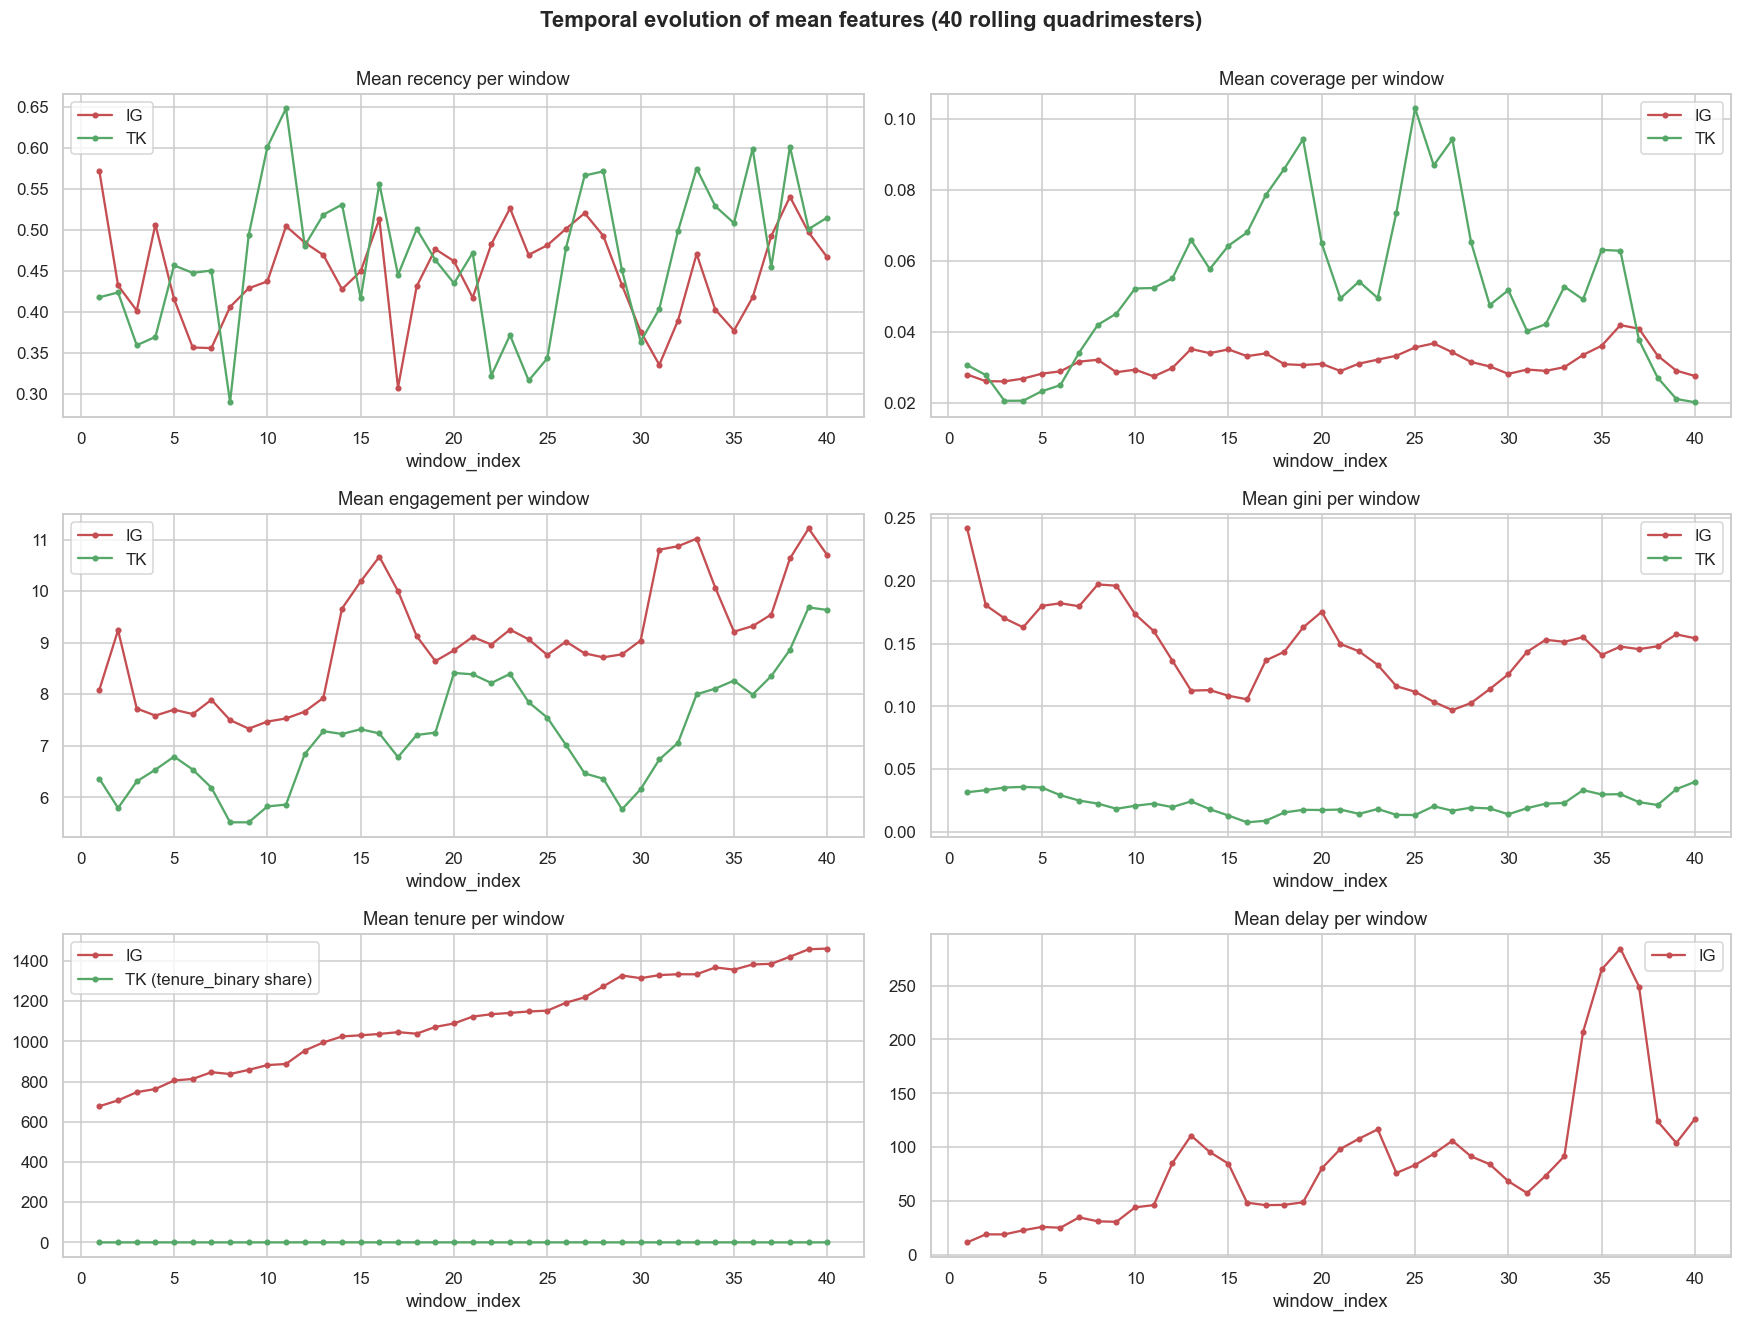

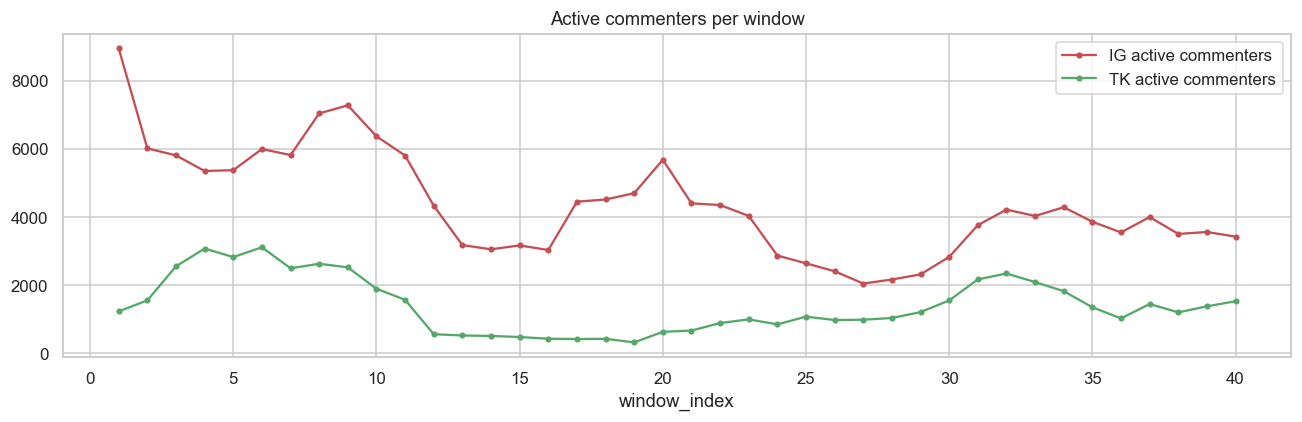

In [18]:
# Order windows chronologically
order = (ig[["window_index", "window_label"]].drop_duplicates()
           .sort_values("window_index"))
labels = order.window_label.tolist()

def window_means(df, feats):
    g = df.groupby("window_index")[feats].mean()
    g = g.reindex(sorted(df.window_index.unique()))
    return g

ig_wm = window_means(ig, IG_FEATURES)
tk_wm = window_means(tk, TK_FEATURES)
# also user counts per window
ig_n = ig.groupby("window_index").size()
tk_n = tk.groupby("window_index").size()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, f in zip(axes.ravel(), ["recency", "coverage", "engagement", "gini", "tenure", "delay"]):
    if f in ig_wm: ax.plot(ig_wm.index, ig_wm[f], "-o", ms=3, label="IG", color="#C44E52")
    if f in tk_wm: ax.plot(tk_wm.index, tk_wm[f], "-o", ms=3, label="TK", color="#55A868")
    if f == "tenure":  # TK tenure is binary share
        ax.plot(tk_wm.index, tk_wm["tenure_binary"], "-o", ms=3, label="TK (tenure_binary share)", color="#55A868")
    ax.set_title(f"Mean {f} per window"); ax.set_xlabel("window_index"); ax.legend()
fig.suptitle("Temporal evolution of mean features (40 rolling quadrimesters)", y=1.0, fontweight="bold")
fig.tight_layout(); save(fig, "temporal_means.png"); plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(ig_n.index, ig_n.values, "-o", ms=3, label="IG active commenters", color="#C44E52")
ax.plot(tk_n.index, tk_n.values, "-o", ms=3, label="TK active commenters", color="#55A868")
ax.set_title("Active commenters per window"); ax.set_xlabel("window_index"); ax.legend()
fig.tight_layout(); save(fig, "active_users_per_window.png"); plt.show()

## 7. Cross-platform correlation (window-aggregate level)

The two user populations are disjoint, so cross-platform correlation is computed on the **40 shared windows**:
for each window we take the platform's mean of every feature, giving two aligned 40-row time series. We then
correlate IG aggregates against TK aggregates. This captures whether the platforms' audiences move *together*
over time (e.g. do engagement waves coincide?).

In [19]:
# Build aligned window-aggregate tables
ig_agg = ig.groupby("window_index")[IG_FEATURES].mean().add_prefix("IG_")
tk_agg = tk.groupby("window_index")[TK_FEATURES].mean().add_prefix("TK_")
ig_agg["IG_n"] = ig.groupby("window_index").size()
tk_agg["TK_n"] = tk.groupby("window_index").size()
agg = ig_agg.join(tk_agg, how="inner")
print("Aligned window-aggregate matrix:", agg.shape)
agg.round(3).head()

Aligned window-aggregate matrix: (40, 13)


,IG_recency,IG_coverage,IG_engagement,IG_delay,IG_tenure,IG_gini,IG_n,TK_recency,TK_coverage,TK_engagement,TK_gini,TK_tenure_binary,TK_n
window_index,,,,,,,,,,,,,
1,0.572,0.028,8.091,11.689,677.560,0.242,8957,0.418,0.031,6.361,0.032,0.117,1230
2,0.432,0.026,9.244,19.176,706.840,0.181,6020,0.424,0.028,5.793,0.033,0.124,1554
3,0.402,0.026,7.724,19.130,747.506,0.170,5814,0.360,0.021,6.309,0.035,0.113,2553
4,0.507,0.027,7.587,22.922,763.297,0.163,5355,0.370,0.021,6.538,0.036,0.130,3075
5,0.416,0.028,7.702,26.076,805.630,0.180,5380,0.457,0.023,6.790,0.035,0.136,2825


,feature,pearson_IGvTK,pearson_p,spearman_IGvTK,spearman_p
0,recency,0.1708,0.2921,0.2013,0.2129
1,coverage,0.5137,0.0007,0.6238,0.0000
2,engagement,0.6360,0.0000,0.6263,0.0000
3,gini,0.5258,0.0005,0.5750,0.0001


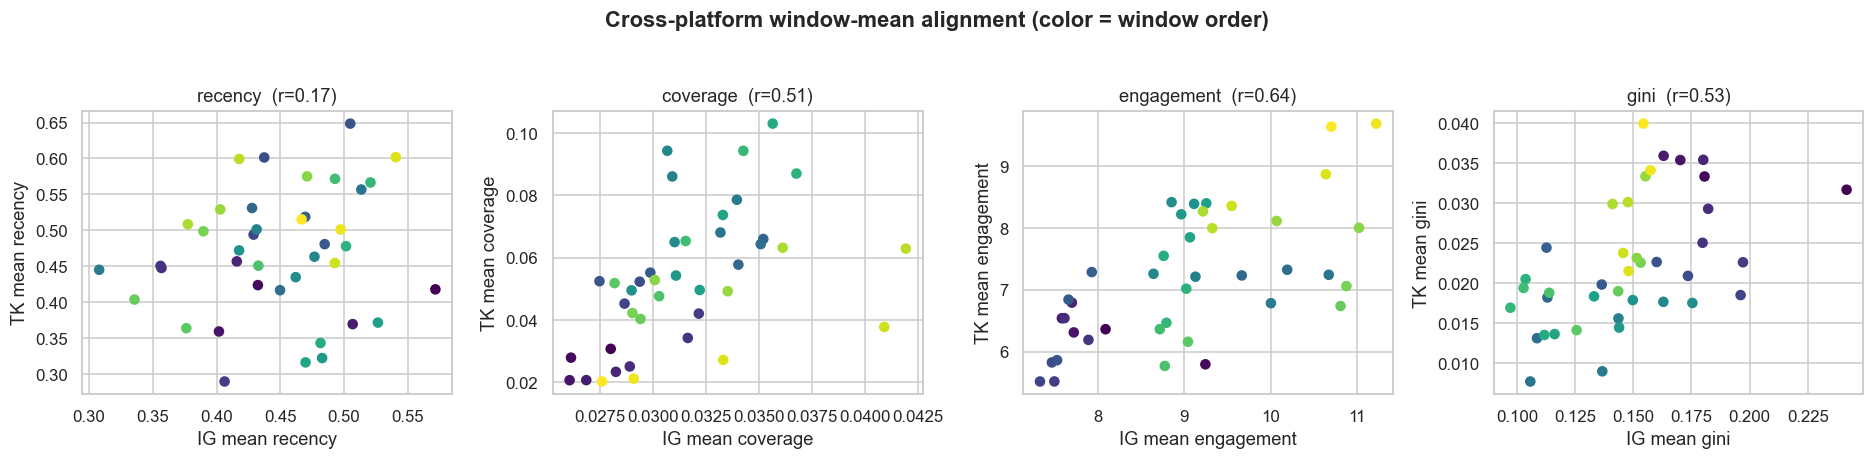

In [20]:
# Same-feature cross-platform correlation over time (Pearson & Spearman)
rows = []
for f in COMMON:
    x, y = agg[f"IG_{f}"], agg[f"TK_{f}"]
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    rows.append({"feature": f, "pearson_IGvTK": pr, "pearson_p": pp,
                 "spearman_IGvTK": sr, "spearman_p": sp})
cross_same = pd.DataFrame(rows).round(4)
display(cross_same)

fig, axes = plt.subplots(1, len(COMMON), figsize=(4.3*len(COMMON), 4))
for ax, f in zip(axes, COMMON):
    ax.scatter(agg[f"IG_{f}"], agg[f"TK_{f}"], c=agg.index, cmap="viridis", s=35)
    ax.set_xlabel(f"IG mean {f}"); ax.set_ylabel(f"TK mean {f}")
    r = cross_same.loc[cross_same.feature==f, "pearson_IGvTK"].values[0]
    ax.set_title(f"{f}  (r={r:.2f})")
fig.suptitle("Cross-platform window-mean alignment (color = window order)", y=1.04, fontweight="bold")
fig.tight_layout(); save(fig, "cross_platform_same_feature.png"); plt.show()

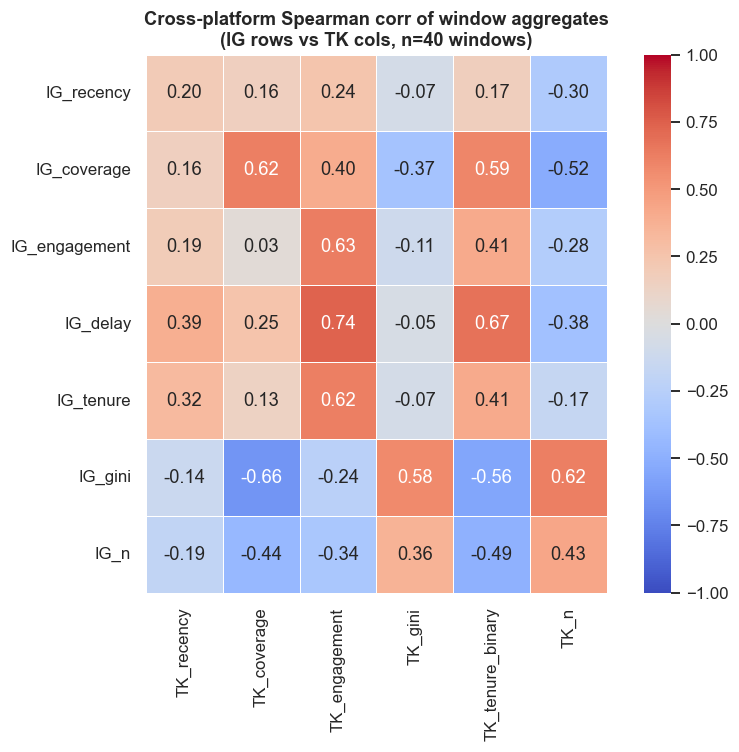

In [21]:
# Full cross-platform correlation block (every IG aggregate vs every TK aggregate)
ig_cols = [c for c in agg.columns if c.startswith("IG_")]
tk_cols = [c for c in agg.columns if c.startswith("TK_")]
cross = agg.corr(method="spearman").loc[ig_cols, tk_cols]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cross, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=.5, square=True, ax=ax)
ax.set_title("Cross-platform Spearman corr of window aggregates\n(IG rows vs TK cols, n=40 windows)", fontweight="bold")
fig.tight_layout(); save(fig, "cross_platform_full_heatmap.png"); plt.show()

In [22]:
# Strongest cross-platform aggregate relationships
m = cross.abs()
top = (m.stack().rename("abs_spearman").reset_index()
         .rename(columns={"level_0":"IG_aggregate","level_1":"TK_aggregate"}))
top["spearman"] = [cross.loc[a,b] for a,b in zip(top.IG_aggregate, top.TK_aggregate)]
top.sort_values("abs_spearman", ascending=False).head(15).round(3)

,IG_aggregate,TK_aggregate,abs_spearman,spearman
20,IG_delay,TK_engagement,0.735,0.735
22,IG_delay,TK_tenure_binary,0.674,0.674
31,IG_gini,TK_coverage,0.655,-0.655
14,IG_engagement,TK_engagement,0.626,0.626
35,IG_gini,TK_n,0.624,0.624
7,IG_coverage,TK_coverage,0.624,0.624
26,IG_tenure,TK_engagement,0.619,0.619
10,IG_coverage,TK_tenure_binary,0.590,0.590
33,IG_gini,TK_gini,0.575,0.575
34,IG_gini,TK_tenure_binary,0.556,-0.556


## 8. Detrended cross-platform check (control for shared time trend)

In [23]:
# Both platforms grow over time; correlating raw means can be driven by a common trend.
# First-difference (window-over-window change) removes the slow trend and tests co-movement of shocks.
agg_d = agg[[f"IG_{f}" for f in COMMON] + [f"TK_{f}" for f in COMMON]].diff().dropna()
rows = []
for f in COMMON:
    x, y = agg_d[f"IG_{f}"], agg_d[f"TK_{f}"]
    sr, sp = stats.spearmanr(x, y)
    rows.append({"feature": f, "spearman_diff_IGvTK": sr, "p": sp})
detrended = pd.DataFrame(rows).round(4)
print("Co-movement of window-over-window CHANGES (trend removed):")
detrended

Co-movement of window-over-window CHANGES (trend removed):


,feature,spearman_diff_IGvTK,p
0,recency,0.2964,0.0670
1,coverage,0.3324,0.0387
2,engagement,0.2194,0.1795
3,gini,0.0502,0.7615


## 9. Summary of findings

Run the cells above; the key reusable artifacts are written to `eda_rfm_outputs/`. When reviewing, focus on:

- **Distributions** — `recency` and `coverage` are bounded and comparable across platforms; `engagement`,
  `delay`, `tenure` are heavy-tailed (use the log/Spearman views). `gini` (both) and `tenure_binary` (TK)
  are spike-at-zero variables dominated by single-comment users.
- **Within-platform structure** — read off `ranked` (Section 4): the strongest, most interpretable couplings are
  typically `coverage`↔`gini` and `coverage`↔`engagement`; `recency`↔`delay` on IG. These are mechanical/behavioural,
  not noise.
- **IG vs TK common features** — Section 3's KS / Mann–Whitney table quantifies how differently the two audiences
  behave on the shared features.
- **Cross-platform (Section 7–8)** — the *meaningful* cross-platform correlations live at the window-aggregate
  level. Compare the raw same-feature correlation (`cross_same`) against the **detrended** first-difference
  version (`detrended`): correlations that survive detrending indicate genuine co-movement of the two audiences,
  while those that vanish were driven by a shared growth trend.
